# 📚 Importing Libaries


In [1]:
# 📚 Core Libraries
import sys
import os
import time
import math
import random

# 🔢 Scientific & Graph Libraries
import numpy as np
import networkx as nx
from scipy.stats import poisson

# 📊 Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt

# ⚙️ Dynamic Style Configuration
mpl_params = {
    "text.usetex": False,   # LaTeX text rendering
    "font.family": "serif", # Font style
    "figure.dpi": 120,      # Image resolution
    "axes.titlesize": 14,   # Title font size
    "axes.labelsize": 12    # Label font size
}
mpl.rcParams.update(mpl_params)


### 🔑 Random Number Generator (64-bit Mersenne Twister style)

In [2]:
def genrand64_int64():
    """
    Generate a pseudo-random 64-bit integer.

    Notes
    -----
    This is a placeholder implementation using Python's built-in
    `random.getrandbits(64)` instead of the original MT19937-64 generator.

    Returns
    -------
    int
        Random 64-bit integer.
    """
    return random.getrandbits(64)


def genrand64_real3():
    """
    Generate a random float in the interval [0, 1).

    Returns
    -------
    float
        A random number uniformly distributed in [0, 1).
    """
    return genrand64_int64() / float(1 << 64)

# ============================================================
# 🔢 Mersenne Twister 64-bit (placeholder using Python's random)
# ============================================================

NN = 312
mt = [0] * NN
mti = 0

def init_genrand64(seed: int):
    """
    Initialize the internal state array for MT19937-64 (placeholder version).

    Notes
    -----
    This is not the full MT19937-64 implementation. For simplicity, it uses
    Python's built-in `random.seed` for pseudo-random number generation,
    while keeping the same function signature and state variables as the
    original algorithm to ensure compatibility with existing code.

    Parameters
    ----------
    seed : int
        Initial seed value for the random number generator.

    Effects
    -------
    - Updates the global state array `mt` and index `mti`.
    - Calls `random.seed(seed)` to synchronize Python's RNG.
    """
    global mt, mti
    random.seed(seed)  # use Python's PRNG as placeholder
    mt[0] = seed
    for mti in range(1, NN):
        mt[mti] = (6364136223846793005 * (mt[mti-1] ^ (mt[mti-1] >> 62)) + mti) & ((1 << 64) - 1)



### 🎯 Random Node Selection

In [3]:
def random_attack_node(N: int) -> int:
    """
    Select a random node uniformly from the set {1, ..., N}.

    Parameters
    ----------
    N : int
        Total number of nodes.

    Returns
    -------
    int
        Index of the randomly selected node (1-indexed).
    """
    return int(genrand64_real3() * N) + 1


### 🔗 Graph Construction

In [4]:
def bond_to_graph(bond, N):
    """
    Convert a 'bond' structure into a NetworkX graph.

    Parameters
    ----------
    bond : list
        Bond structure where `bond[0][i]` represents the degree of node i,
        and `bond[i][k]` (k ≥ 1) stores the neighbors of node i.
    N : int
        Number of nodes.

    Returns
    -------
    networkx.Graph
        Undirected graph corresponding to the bond structure.
    """
    G = nx.Graph()
    G.add_nodes_from(range(1, N + 1))
    for i in range(1, N + 1):
        for idx in range(1, bond[0][i] + 1):
            j = bond[i][idx]
            if i < j:  # Avoid duplicates
                G.add_edge(i, j)
    return G


### 🧩 Hub-Based Node Selection

In [5]:
def get_hub_nodes(N, bond, top_k=1):
    """
    Get the top-k hub nodes by degree.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond structure as described in `bond_to_graph`.
    top_k : int, optional
        Number of nodes to return (default = 1).

    Returns
    -------
    list of int
        Node indices of the top-k hubs.
    """
    degree_list = [(bond[0][i], i) for i in range(1, N + 1)]
    degree_list.sort(key=lambda x: x[0], reverse=True)
    return [i for _, i in degree_list[:top_k]]


def select_hub_node(N, bond, top_k=1):
    """
    Select one node among the top-k hubs (random tie-breaking).

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond structure as described in `bond_to_graph`.
    top_k : int, optional
        Number of hubs to consider (default = 1).

    Returns
    -------
    int or None
        Selected hub node index, or None if no hubs exist.
    """
    hubs = get_hub_nodes(N, bond, top_k=top_k)
    return random.choice(hubs) if hubs else None


### 🧩 Closeness-Based Node Selection

In [6]:
def get_closeness_nodes(N, bond, top_k=1):
    """
    Get the top-k nodes by closeness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond structure as described in `bond_to_graph`.
    top_k : int, optional
        Number of nodes to return (default = 1).

    Returns
    -------
    list of int
        Node indices ranked by closeness centrality.
    """
    G = bond_to_graph(bond, N)
    clos = nx.closeness_centrality(G)
    ordered = sorted(clos.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]


def select_closeness_node(N, bond, top_k=1):
    """
    Select one node among the top-k by closeness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond structure as described in `bond_to_graph`.
    top_k : int, optional
        Number of nodes to consider (default = 1).

    Returns
    -------
    int or None
        Selected node index, or None if no nodes exist.
    """
    nodes = get_closeness_nodes(N, bond, top_k=top_k)
    return random.choice(nodes) if nodes else None


### 🧩 Betweenness-Based Node Selection

In [7]:
def get_betweenness_nodes(N, bond, top_k=1, normalized=True):
    """
    Get the top-k nodes by betweenness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond structure as described in `bond_to_graph`.
    top_k : int, optional
        Number of nodes to return (default = 1).
    normalized : bool, optional
        If True, normalize betweenness scores (default = True).

    Returns
    -------
    list of int
        Node indices ranked by betweenness centrality.
    """
    G = bond_to_graph(bond, N)
    btw = nx.betweenness_centrality(G, normalized=normalized)
    ordered = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)
    return [n for n, _ in ordered[:top_k]]


def select_betweenness_node(N, bond, top_k=1, normalized=True):
    """
    Select one node among the top-k by betweenness centrality.

    Parameters
    ----------
    N : int
        Number of nodes.
    bond : list
        Bond structure as described in `bond_to_graph`.
    top_k : int, optional
        Number of nodes to consider (default = 1).
    normalized : bool, optional
        If True, normalize betweenness scores (default = True).

    Returns
    -------
    int or None
        Selected node index, or None if no nodes exist.
    """
    nodes = get_betweenness_nodes(N, bond, top_k=top_k, normalized=normalized)
    return random.choice(nodes) if nodes else None


### ⚙️ Network Utility Functions (bond structure)

In [8]:
def find_node(i, j, bond):
    """
    Find the neighbor index of node j in the adjacency list of node i.

    Parameters
    ----------
    i : int
        Index of the source node (1-indexed).
    j : int
        Index of the target node to search for.
    bond : list
        Bond structure where:
        - bond[0][i] = degree of node i
        - bond[i][1..degree(i)] = neighbors of node i

    Returns
    -------
    int
        Index k such that bond[i][k] == j (1 ≤ k ≤ degree(i)),
        or -1 if node j is not a neighbor of i.
    """
    for k in range(1, bond[0][i] + 1):
        if bond[i][k] == j:
            return k
    return -1


def copy_network(N, origin_bond, copy_bond):
    """
    Copy degrees and neighbor lists from one bond structure to another.

    Parameters
    ----------
    N : int
        Number of nodes.
    origin_bond : list
        Source bond structure to copy from.
    copy_bond : list
        Destination bond structure to copy into.

    Notes
    -----
    Both bond structures are assumed to be 1-indexed. For each node i,
    this function copies:
    - degree(origin_bond[i]) → copy_bond[0][i]
    - adjacency list → copy_bond[i]
    """
    for i in range(1, N + 1):
        deg = origin_bond[0][i]
        copy_bond[0][i] = deg
        copy_bond[i] = origin_bond[i][:deg + 1]


# ============================================================
# 🌐 GERAÇÃO DA REDE QUÂNTICA (Waxman + Fotônica)
# ============================================================

In [ ]:
'''# Parâmetros padrão
R_default = 1800
aL = 226
b = 1
g = 0.2
np_photons = 1000
A_value = 5.2e4  # não usado nesta versão

def generate_waxman_graph(N, R, aL, b):
    """
    Gera um grafo Waxman com N nós distribuídos uniformemente em disco de raio R.
    Retorna: (G, nodes), onde nodes = coordenadas (x,y).
    """
    G = nx.Graph()
    G.add_nodes_from(range(N))
    r = R * np.sqrt(np.random.uniform(0, 1, N))
    theta = np.random.uniform(0, 2 * np.pi, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    nodes = np.column_stack((x, y))
    dij = np.sqrt((x[:, None] - x)**2 + (y[:, None] - y)**2)
    Pij = b * np.exp(-dij / aL)
    mask = np.triu(np.random.uniform(0, 1, size=(N, N)) < Pij, 1)
    ii, jj = np.where(mask)
    for i, j in zip(ii, jj):
        G.add_edge(i, j, weight=dij[i, j])
    return G, nodes

def generate_photonic_network(G, g, np_photons):
    """
    A partir do grafo de fibra G, cria a rede fotônica H.
    Pij = 1 - (1 - pij)**np_photons, com pij = 10^(-g * dij / 10).
    """
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for i, j, data in G.edges(data=True):
        dij = data['weight']
        pij = 10**(-g * dij / 10)
        Pij = 1 - (1 - pij)**np_photons
        if np.random.rand() < Pij:
            H.add_edge(i, j, weight=dij)
    return H

def generate_quantum_network_bond(N, bond):
    """
    Gera rede fotônica H e converte para 'bond' (1-index).
    Retorna as posições dos nós (coordenadas).
    """
    G, nodes = generate_waxman_graph(N, R_default, aL, b)
    H = generate_photonic_network(G, g, np_photons)
    for i in range(1, N+1):
        bond[0][i] = 0
        bond[i] = [0]
    for (i, j) in H.edges():
        i1, j1 = i + 1, j + 1
        bond[0][i1] += 1
        bond[i1].append(j1)
        bond[0][j1] += 1
        bond[j1].append(i1)
    return nodes
'''

In [ ]:
import os
from pathlib import Path
import networkx as nx

def generate_ba_graph(N: int, m: int, seed: int | None = None) -> nx.Graph:
    """
    Gera uma rede Barabási–Albert (scale-free) com N nós,
    anexando m arestas a cada novo nó.
    """
    G = nx.barabasi_albert_graph(N, m, seed=seed)
    G.remove_edges_from(nx.selfloop_edges(G))  # por garantia
    return G

def save_graph_as_txt(G: nx.Graph, out_dir: str = "network-save", filename: str = "graph.txt") -> str:
    """
    Salva o grafo em formato edgelist (u v por linha) em out_dir/filename.
    Retorna o caminho salvo.
    """
    os.makedirs(out_dir, exist_ok=True)
    path = Path(out_dir) / filename
    nx.write_edgelist(G, path, data=False)
    return str(path)

# — Exemplo de uso —
N, m, seed = 5000, 3, 42
G = generate_ba_graph(N, m, seed=seed)
txt_path = save_graph_as_txt(G, filename=f"ba_N{N}_m{m}.txt")
print("Salvo em:", txt_path)

Salvo em: network-save\ba_N5000_m3.txt


In [1]:
import networkx as nx
from pathlib import Path

def load_graph_from_txt(path: str) -> nx.Graph:
    """
    Lê um grafo salvo como edgelist em texto (u v por linha) e
    retorna um grafo simples, não-direcionado, sem self-loops.
    """
    G = nx.read_edgelist(
        path,
        create_using=nx.Graph(),  # garante não-direcionado
        nodetype=int,             # nós como inteiros (ajuste se precisar str)
        data=False,               # sem atributos
        comments="#",             # ignora linhas que começam com '#'
    )
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

# Exemplo de uso:
txt_path = "network-save/ba_N1000_m3.txt"
G = load_graph_from_txt(txt_path)
print(G.number_of_nodes(), G.number_of_edges())


1000 2991


In [ ]:
import networkx as nx
import numpy as np
from typing import List, Dict, Tuple, Optional

def generate_network_bond(G: nx.Graph, bond: List[List[int]], positions: Optional[Dict] = None) -> np.ndarray:
    """
    Converte qualquer grafo NetworkX em 'bond' (1-index) e retorna as coordenadas.

    Parâmetros
    ----------
    G : nx.Graph
        Grafo de entrada (qualquer formato, rótulos arbitrários).
    bond : list of lists
        Estrutura 'bond' a ser preenchida:
        - bond[0][i] = grau(i)
        - bond[i][1..grau(i)] = vizinhos de i
        Índices 1-indexados.
    positions : dict, opcional
        Dicionário {node: (x,y)} com posições. Se None, gera automaticamente
        com `spring_layout`.

    Retorna
    -------
    coords : np.ndarray de shape (N, 2)
        Coordenadas alinhadas ao índice 1..N usado em bond.
    """
    # Garantir grafo simples, não-direcionado
    if G.is_directed():
        G = G.to_undirected()
    if isinstance(G, nx.MultiGraph):
        G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Relabel para ids consecutivos 1..N
    nodes_sorted = sorted(G.nodes())
    old_to_new = {u: i+1 for i, u in enumerate(nodes_sorted)}
    G1 = nx.relabel_nodes(G, old_to_new, copy=True)
    N = G1.number_of_nodes()

    # Resetar bond
    for i in range(1, N+1):
        bond[0][i] = 0
        bond[i] = [0]

    # Preencher bond
    for (i, j) in G1.edges():
        bond[0][i] += 1
        bond[i].append(j)
        bond[0][j] += 1
        bond[j].append(i)

    # Posições
    if positions is None:
        pos = nx.spring_layout(G1, seed=42)  # gera coords
    else:
        # reindexar positions de acordo com mapeamento old_to_new
        pos = {old_to_new[u]: np.asarray(xy, dtype=float) for u, xy in positions.items()}

    coords = np.zeros((N, 2))
    for i in range(1, N+1):
        coords[i-1] = pos[i]

    return coords


In [ ]:
# Gerar grafo BA
G = nx.barabasi_albert_graph(100, 3, seed=1)

# Criar bond vazio
N = G.number_of_nodes()
bond = [[] for _ in range(N+1)]
bond[0] = [0]*(N+1)

coords = generate_network_bond(G, bond)

print("N=", N, "E=", G.number_of_edges())
print("grau do nó 1:", bond[0][1], "vizinhos:", bond[1][1:])
print("coords[0] =", coords[0])


-----
--------

### 🔍 BFS & Shortest Paths

In [10]:
def clean_time_stamp(update_time, E):
    """
    Reset all timestamps to zero.

    Parameters
    ----------
    update_time : list
        Array of timestamps.
    E : int
        Number of edges to reset.
    """
    for i in range(1, E+1):
        update_time[i] = 0


def simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    Breadth-first search (BFS) up to distance C, or until reaching the target.

    Parameters
    ----------
    C : int
        Distance budget.
    N : int
        Number of nodes.
    bond : list
        Bond structure (adjacency list).
    source : int
        Starting node.
    target : int
        Target node (if target < 0, BFS explores fully).
    vec, tmp_vec, visited, reset, dag, nr_sp : list
        Auxiliary arrays used for BFS traversal.

    Returns
    -------
    int
        Status code:
        - 0 : explored fully without reaching C or target
        - 1 : reached distance C
        - 2 : reached the target
    """
    int_distance = 0
    control = 0
    vec[0] = 1
    vec[1] = source
    visited[source] = 0
    dag[0][source] = 0
    nr_sp[source] = 1
    reset[0] = 1
    reset[1] = source
    while vec[0] > 0 and control == 0:
        tmp_vec[0] = 0
        int_distance += 1
        if int_distance == C:
            control = 1
        for i in range(1, vec[0] + 1):
            n = vec[i]
            for j in range(1, bond[0][n] + 1):
                m = bond[n][j]
                if m == target:
                    control = 2
                if visited[m] < 0:
                    tmp_vec[0] += 1
                    tmp_vec[tmp_vec[0]] = m
                    visited[m] = visited[n] + 1
                    reset[0] += 1
                    reset[reset[0]] = m
                if visited[m] == int_distance:
                    dag[0][m] += 1
                    dag[m][dag[0][m]] = n
                    nr_sp[m] += nr_sp[n]
        for i2 in range(tmp_vec[0] + 1):
            vec[i2] = tmp_vec[i2]
    return control


def sample_random_path(C, N, dag, source, target, path, nr_sp):
    """
    Sample one shortest path from target to source using a DAG.

    Parameters
    ----------
    C : int
        Distance budget.
    N : int
        Number of nodes.
    dag : list
        Predecessor DAG built from BFS.
    source : int
        Starting node.
    target : int
        Target node.
    path : list
        Array to store the sampled path.
    nr_sp : list
        Number of shortest paths to each node.

    Notes
    -----
    The path is sampled with probability proportional to the number of
    shortest paths through each predecessor.
    """
    control = 0
    path[0] = 1
    path[1] = target
    while control == 0:
        n = path[path[0]]
        if dag[0][n] > 0:
            T = 0
            for i in range(1, dag[0][n] + 1):
                T += nr_sp[dag[n][i]]
            q = int(genrand64_real3() * T) + 1
            if q > T:
                q = 1
            i = 0
            acc = 0
            found = 0
            while found == 0:
                i += 1
                acc += nr_sp[dag[n][i]]
                if q <= acc:
                    found = dag[n][i]
            path[0] += 1
            path[path[0]] = found
            if path[0] == C + 1 or path[path[0]] == source:
                control = 1
        else:
            path[0] = 0
            return


def get_path_of_pair(source, target, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp):
    """
    Compute and sample one shortest path between (source, target), limited by C.

    Parameters
    ----------
    source : int
        Source node.
    target : int
        Target node.
    C : int
        Distance budget.
    N : int
        Number of nodes.
    bond : list
        Bond structure (adjacency list).
    path, vec, tmp_vec, visited, reset, dag, nr_sp : list
        Auxiliary arrays used in BFS.

    Returns
    -------
    int
        Length of the sampled path, or 0 if no path exists.
    """
    control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
    path[0] = 0
    if control == 2:
        sample_random_path(C, N, dag, source, target, path, nr_sp)
    for i in range(1, reset[0] + 1):
        node = reset[i]
        visited[node] = -1
        dag[0][node] = 0
        nr_sp[node] = 0
    return path[0]

###  🎲 Probability Utilities

In [11]:
def geometric_distribution(P: float) -> int:
    """
    Sample from a geometric distribution with parameter P.

    Parameters
    ----------
    P : float
        Success probability in (0, 1].

    Returns
    -------
    int
        A random integer k ≥ 1 with probability (1-P)^(k-1) * P.
        Returns -1 if P <= 0 (degenerate case).
    """
    if P <= 0:
        return -1
    if P == 1:
        return 1
    u = genrand64_real3()
    return int(1 + math.floor(math.log(u) / math.log(1. - P)))


### 🔀 Pair Management

In [12]:
def adjust_pair(pairs, q):
    """
    Move the pair at position q to the end of the active list.

    Parameters
    ----------
    pairs : list
        Pair structure:
        - pairs[0] = list of first nodes
        - pairs[1] = list of second nodes
        - pairs[0][0] = number of active pairs
    q : int
        Index of the pair to move.

    Notes
    -----
    After the move, the number of active pairs is decreased by 1.
    """
    node1 = pairs[0][q]
    node2 = pairs[1][q]
    pairs[0][q] = pairs[0][pairs[0][0]]
    pairs[1][q] = pairs[1][pairs[0][0]]
    pairs[0][pairs[0][0]] = node1
    pairs[1][pairs[0][0]] = node2
    pairs[0][0] -= 1


### 💥 Attack Strategies (Random / Hubs / Closeness / Betweenness/ DominiRank)

In [13]:
def _core_pair_removal_loop(C, N, bond, edges, E, update_time, threshold, source_selector):
    """
    Core routine for pair-removal attacks.

    At each iteration, selects a pair of nodes (n, m), where:
    - n is chosen according to a given `source_selector` strategy
    - m is chosen uniformly at random (distinct from n)

    If a shortest path exists between (n, m) within budget C, one such path
    is sampled and its edges are removed from the network. The process
    continues until a given number of consecutive failures is reached.

    Parameters
    ----------
    C : int
        Maximum path length (budget). If C == -1, search is unrestricted.
    N : int
        Number of nodes in the network.
    bond : list
        Bond structure (adjacency list).
    edges : list
        Array to store removed edges:
        - edges[0][k], edges[1][k] are endpoints of edge k
        - edges[0][0] = number of removed edges
    E : int
        Total number of edges.
    update_time : list
        Array of edge update timestamps.
    threshold : int
        Maximum number of consecutive failures before termination.
    source_selector : callable
        Function returning a candidate source node (or None).

    Notes
    -----
    - Removal is performed along one sampled shortest path.
    - For each removed edge (s, t), adjacency lists are updated in-place.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    count_E = 0
    tau = 1
    num_failures = 0

    while num_failures < threshold:
        # choose n by strategy and m uniformly at random
        n = source_selector()
        if n is None:
            edges[0][0] = 0
            return
        m = random_attack_node(N)
        while m == n:
            m = random_attack_node(N)

        if bond[0][n] > bond[0][m]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            num_failures = 0
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v1 = find_node(s, t, bond)
                bond[s][v1] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v2 = find_node(t, s, bond)
                bond[t][v2] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                count_E += 1
                if s < t:
                    edges[0][count_E] = s
                    edges[1][count_E] = t
                else:
                    edges[0][count_E] = t
                    edges[1][count_E] = s
                update_time[count_E] += tau
        else:
            num_failures += 1

        tau += 1

    for i in range(count_E + 1, E + 1):
        update_time[i] += tau

    edges[0][0] = count_E


def remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold):
    """
    Random attack: both n and m are chosen uniformly at random.

    Wrapper around `_core_pair_removal_loop` using random node selection.
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: random_attack_node(N)
    )


def remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Hub-based attack: n is chosen among the top-k highest degree nodes.

    Parameters
    ----------
    top_k : int, optional
        Number of hubs to consider (default = 1).
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_hub_node(N, bond, top_k=top_k)
    )


def remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Closeness-based attack: n is chosen among the top-k nodes ranked by closeness centrality.

    Parameters
    ----------
    top_k : int, optional
        Number of nodes to consider (default = 1).
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_closeness_node(N, bond, top_k=top_k)
    )


def remove_pair_wo_pair_info_v2_betweenness(C, N, bond, edges, E, update_time, threshold, top_k=1):
    """
    Betweenness-based attack: n is chosen among the top-k nodes ranked by betweenness centrality.

    Parameters
    ----------
    top_k : int, optional
        Number of nodes to consider (default = 1).
    """
    _core_pair_removal_loop(
        C, N, bond, edges, E, update_time, threshold,
        source_selector=lambda: select_betweenness_node(N, bond, top_k=top_k, normalized=True)
    )


### 🔗 Precomputed Pair Handling (Generation & Removal)

In [14]:
def remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time):
    """
    Remove edges by following shortest paths between precomputed node pairs.

    Parameters
    ----------
    C : int
        Maximum path length (budget). If C == -1, search is unrestricted.
    N : int
        Number of nodes in the network.
    bond : list
        Bond structure (adjacency list).
    pairs : list
        Pair structure:
        - pairs[0][0] = number of active pairs
        - pairs[0][i], pairs[1][i] = endpoints of pair i
    edges : list
        Array to store removed edges:
        - edges[0][k], edges[1][k] = endpoints of edge k
        - edges[0][0] = number of removed edges
    update_time : list
        Array of edge update timestamps.

    Notes
    -----
    - Pairs are consumed sequentially. If a path exists for a pair,
      all edges along it are removed.
    - Removal intervals are sampled from a geometric distribution with
      probability depending on the number of active pairs.
    - After each removal, BFS is used to check connectivity. If a pair
      becomes invalid, it is adjusted with `adjust_pair`.
    """
    path = [0] * (N+1)
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag = []
    for i in range(N+1):
        dag.append([0] * (N+1 if i == 0 else (bond[0][i] + 1)))

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    interval = 0
    E = edges[0][0]

    while pairs[0][0] > 0:
        num_pairs = pairs[0][0]
        link_prob = 2.0 * float(num_pairs) / (float(N) * float(N - 1))
        interval += geometric_distribution(link_prob)

        q = int(genrand64_real3() * num_pairs + 1)
        n = pairs[0][q]
        m = pairs[1][q]

        source = n
        target = m
        if bond[0][source] > bond[0][target]:
            n, m = m, n

        if C == -1:
            p = get_path_of_pair(n, m, N, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)
        else:
            p = get_path_of_pair(n, m, C, N, bond, path, vec, tmp_vec, visited, reset, dag, nr_sp)

        if p > 0:
            for j in range(1, path[0]):
                s = path[j]
                t = path[j+1]

                v = find_node(s, t, bond)
                bond[s][v] = bond[s][bond[0][s]]
                bond[0][s] -= 1

                v = find_node(t, s, bond)
                bond[t][v] = bond[t][bond[0][t]]
                bond[0][t] -= 1

                E += 1
                if s < t:
                    edges[0][E] = s
                    edges[1][E] = t
                else:
                    edges[0][E] = t
                    edges[1][E] = s
                update_time[E] += interval

            control = simple_bfs(C, N, bond, n, m, vec, tmp_vec, visited, reset, dag, nr_sp)
            if control == 1:
                adjust_pair(pairs, q)
        else:
            adjust_pair(pairs, q)

        for i2 in range(1, reset[0] + 1):
            node = reset[i2]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    edges[0][0] = E


def find_all_possible_pairs(C, N, bond, pairs):
    """
    Find all node pairs connected by shortest paths of length ≤ C.

    Parameters
    ----------
    C : int
        Maximum path length (budget). If C == -1, all pairs are considered.
    N : int
        Number of nodes.
    bond : list
        Bond structure (adjacency list).
    pairs : list
        Output pair structure:
        - pairs[0][0] = number of pairs found
        - pairs[0][i], pairs[1][i] = endpoints of pair i

    Returns
    -------
    int
        Total number of pairs found.

    Notes
    -----
    - Uses BFS from each source node to discover reachable targets.
    - Pairs are stored without duplicates (i < j).
    """
    num_pairs = 0
    dag = []
    list_pairs = []
    vec = [0] * (N+1)
    tmp_vec = [0] * (N+1)
    visited = [-1] * (N+1)
    reset = [0] * (N+1)
    nr_sp = [0] * (N+1)

    dag.append([0] * (N+1))
    for i in range(1, N+1):
        dag.append([0] * (bond[0][i] + 1))

    list_pairs.append([0] * (N+1))
    for i in range(1, N+1):
        list_pairs.append([0])

    for i in range(1, N+1):
        visited[i] = -1
        dag[0][i] = 0
        nr_sp[i] = 0

    target = -1
    for source in range(1, N+1):
        control = simple_bfs(C, N, bond, source, target, vec, tmp_vec, visited, reset, dag, nr_sp)
        for k in range(1, reset[0] + 1):
            n = reset[k]
            if source < n and find_node(source, n, list_pairs) < 0:
                list_pairs[0][source] += 1
                list_pairs[source].append(n)
                num_pairs += 1
        for k in range(1, reset[0] + 1):
            node = reset[k]
            visited[node] = -1
            dag[0][node] = 0
            nr_sp[node] = 0

    while len(pairs[0]) < num_pairs + 1:
        pairs[0].append(0)
    while len(pairs[1]) < num_pairs + 1:
        pairs[1].append(0)

    num_pairs = 0
    for i in range(1, N+1):
        for j in range(1, list_pairs[0][i] + 1):
            num_pairs += 1
            pairs[0][num_pairs] = i
            pairs[1][num_pairs] = list_pairs[i][j]

    pairs[0][0] = num_pairs
    return num_pairs


### 🌳 Largest Cluster Tracking (Union-Find / Modified NZ Algorithm)

In [15]:
def tree_find_root(n, root, res):
    """
    Find the root of node n in a union-find structure (with path compression).

    Parameters
    ----------
    n : int
        Node index to search.
    root : list of lists
        Union-find structure:
        - root[0][i] = parent of node i
        - root[1][i] = size of component if i is a root
    res : list
        Output array storing:
        - res[0] = root of n
        - res[1] = size of the component containing n

    Notes
    -----
    This is a recursive implementation of path compression.
    """
    if root[0][n] == n:
        res[0] = root[0][n]
        res[1] = root[1][n]
        return
    tree_find_root(root[0][n], root, res)


def modified_NZ_algorithm(N, edges, largest_cluster):
    """
    Reconstruct clusters from edge-removal order and compute metrics
    of the largest connected component at each step.

    Parameters
    ----------
    N : int
        Number of nodes.
    edges : list
        Edge-removal structure:
        - edges[0][0] = total number of removed edges
        - edges[0][e], edges[1][e] = endpoints of edge e (removal order)
    largest_cluster : list
        Array to store largest cluster statistics:
        - largest_cluster[k][e] stores kth moment of largest cluster size
          at step e (k = 1..5)

    Notes
    -----
    - Uses a union-find structure to merge components in reverse
      order of edge removals.
    - At each step, updates:
        * size fraction of largest cluster
        * squared, cubic, quartic powers
        * average squared component size (excluding largest)
    """
    root = [[0]*(N+1), [0]*(N+1)]
    res = [0, 0]
    larg = 1
    av2 = float(N - 1)

    for i in range(1, N+1):
        root[0][i] = i
        root[1][i] = 1

    E = edges[0][0]
    for e in range(E, 0, -1):
        n = edges[0][e]
        m = edges[1][e]
        av2 += float(larg) * float(larg)

        tree_find_root(n, root, res)
        rn, sn = res[0], res[1]
        tree_find_root(m, root, res)
        rm, sm = res[0], res[1]

        if rn != rm:
            av2 -= float(sn) * float(sn)
            av2 -= float(sm) * float(sm)
            if sn > sm:
                root[0][rm] = rn
                root[1][rm] = 1
                root[1][rn] = sn + sm
            else:
                root[0][rn] = rm
                root[1][rn] = 1
                root[1][rm] = sn + sm
            if sn + sm > larg:
                larg = sn + sm

        tmp = float(larg) / float(N)
        largest_cluster[1][e] = tmp
        largest_cluster[2][e] = tmp * tmp
        largest_cluster[3][e] = tmp * tmp * tmp
        largest_cluster[4][e] = tmp * tmp * tmp * tmp

        av = float(N) - float(larg)
        if rn != rm:
            av2 += float(sn + sm) * float(sn + sm)
        av2 -= float(larg) * float(larg)

        if av > 0:
            largest_cluster[5][e] = av2 / av


### 🧠 Attack Orchestrator

In [16]:
def efficient_pair_removal(C, N, bond, edges, E, update_time, threshold,
                           hub_mode=False, closeness_mode=False, betweenness_mode=False, top_k=1):
    """
    Select and execute an attack strategy, then run the post-processing pipeline.

    Strategies
    ----------
    - Random      : default mode
    - Hubs        : if hub_mode = True
    - Closeness   : if closeness_mode = True
    - Betweenness : if betweenness_mode = True

    Priority
    --------
    If multiple modes are enabled simultaneously:
    betweenness > closeness > hubs > random

    Parameters
    ----------
    C : int
        Maximum path length (budget). If C == -1, search is unrestricted.
    N : int
        Number of nodes.
    bond : list
        Bond structure (adjacency list).
    edges : list
        Edge-removal structure:
        - edges[0][0] = number of removed edges
        - edges[0][e], edges[1][e] = endpoints of edge e
    E : int
        Total number of edges.
    update_time : list
        Array of edge update timestamps.
    threshold : int
        Maximum number of consecutive failures before termination.
    hub_mode : bool, optional
        Enable hub-based attack strategy.
    closeness_mode : bool, optional
        Enable closeness-based attack strategy.
    betweenness_mode : bool, optional
        Enable betweenness-based attack strategy.
    top_k : int, optional
        Number of nodes considered in hub/closeness/betweenness strategies (default = 1).

    Notes
    -----
    - This function orchestrates the attack pipeline:
        1. Execute initial pair-removal attack according to selected strategy.
        2. Compute all possible pairs (`find_all_possible_pairs`).
        3. Continue removal using precomputed pairs (`remove_pair_w_pair_info_v2`).
    """
    if betweenness_mode:
        remove_pair_wo_pair_info_v2_betweenness(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
    elif closeness_mode:
        remove_pair_wo_pair_info_v2_closeness(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
    elif hub_mode:
        remove_pair_wo_pair_info_v2_hubs(C, N, bond, edges, E, update_time, threshold, top_k=top_k)
    else:
        remove_pair_wo_pair_info_v2(C, N, bond, edges, E, update_time, threshold)

    # Subsequent pipeline (same as original implementation)
    pairs = [[0], [0]]
    find_all_possible_pairs(C, N, bond, pairs)
    remove_pair_w_pair_info_v2(C, N, bond, pairs, edges, update_time)


### 🚀 Main Simulation Runner 


In [17]:
def main(N_values=[300, 500, 600, 1000],
         C_values=None,
         num_iter=1000,
         num_instance=1,
         hub_mode=False,
         closeness_mode=False,
         betweenness_mode=False,
         top_k=1,
         output_dir="./data"):
    """
    Run Shortest Path Percolation (SPP) simulations for multiple N and C values.

    Parameters
    ----------
    N_values : list of int, default=[300, 500, 600, 1000]
        List of network sizes to simulate.
    C_values : list of int or None, default=None
        List of path budgets. If None, defaults to [1, 2, 3, N] for each N.
        If the list contains the literal `N`, it will be replaced by
        the current network size in the loop.
    num_iter : int, default=1000
        Number of iterations per instance.
    num_instance : int, default=1
        Number of independent runs.
    hub_mode : bool, default=False
        If True, use hub-based attack strategy.
    closeness_mode : bool, default=False
        If True, use closeness-based attack strategy.
    betweenness_mode : bool, default=False
        If True, use betweenness-based attack strategy.
    top_k : int, default=1
        Number of top nodes considered for hub/closeness/betweenness strategies.
    output_dir : str, default="./data"
        Directory where results will be saved.

    Notes
    -----
    - Results are saved as CSV in subfolders:
      {output_dir}/N{N}/{mode}/C{C}/full_data_<id>.csv
    - Each CSV stores:
      * fraction of removed edges
      * largest cluster size (moments 1–5)
      * removed edges (u, v)
      * removal timestamps
    """
    start = time.time()

    for N in N_values:
        # Handle default or placeholder C values
        if C_values is None:
            C_list = [1, 2, 3, N]
        else:
            C_list = [c if c != "N" else N for c in C_values]

        for C in C_list:
            print(f"Starting simulation: N={N}, C={C}, "
                  f"hub={hub_mode}, closeness={closeness_mode}, betweenness={betweenness_mode}")

            # Initialize adjacency structure
            bond = [[] for _ in range(N+1)]
            bond[0] = [0] * (N+1)
            for i in range(1, N+1):
                bond[i] = [0]

            copy_bond = [[] for _ in range(N+1)]
            copy_bond[0] = [0] * (N+1)

            E = 0
            edges = [[0], [0]]
            update_time = [0]
            largest_cluster = [[0.0] * (E+1) for _ in range(6)]

            # Random seed
            pid_id = int(time.time()) * os.getpid()
            init_genrand64(pid_id)

            for _ in range(num_instance):
                generate_quantum_network_bond(N, bond)
                E = int(sum(bond[0][i] for i in range(1, N+1)) // 2)
                edges = [[0] * (E+1), [0] * (E+1)]
                update_time = [0] * (E+1)
                largest_cluster = [[0.0] * (E+1) for _ in range(6)]

                for iteration in range(num_iter):
                    copy_network(N, bond, copy_bond)
                    clean_time_stamp(update_time, E)
                    threshold = int(7 * (N**0.44))

                    # Run attack strategy
                    efficient_pair_removal(
                        C, N, copy_bond, edges, E, update_time, threshold,
                        hub_mode=hub_mode,
                        closeness_mode=closeness_mode,
                        betweenness_mode=betweenness_mode,
                        top_k=top_k
                    )

                    # Compute largest cluster
                    modified_NZ_algorithm(N, edges, largest_cluster)

                    # Save results
                    mode_name = ("betweenness_attack" if betweenness_mode else
                                 "closeness_attack" if closeness_mode else
                                 "hub_attack" if hub_mode else "random")
                    C_folder = C if C > 0 else N
                    dir_path = f"{output_dir}/N{N}/{mode_name}/C{C_folder}/"
                    os.makedirs(dir_path, exist_ok=True)

                    file_id = iteration
                    file_name = f"{dir_path}full_data_{file_id}.csv"
                    with open(file_name, "w") as f:
                        for j in range(1, edges[0][0] + 1):
                            removed_edges = float(j) / float(edges[0][0])
                            f.write(
                                f"{removed_edges:.10f} "
                                f"{largest_cluster[1][j]:.10f} "
                                f"{largest_cluster[2][j]:.10f} "
                                f"{largest_cluster[3][j]:.10f} "
                                f"{largest_cluster[4][j]:.10f} "
                                f"{largest_cluster[5][j]:.10f} "
                                f"{edges[0][j]} "
                                f"{edges[1][j]} "
                                f"{update_time[j]}\n"
                            )
            print(f"Finished simulation: N={N}, C={C}\n")

    end = time.time()
    print(f"Total time: {end - start:.2f} seconds")


In [18]:
main(N_values=[300, 500, 600, 1000],
     C_values=[1, 2, 3, "N"],
     num_iter=10**3,
     num_instance=1,
     hub_mode=False)


Starting simulation: N=300, C=1, hub=False, closeness=False, betweenness=False
Finished simulation: N=300, C=1

Starting simulation: N=300, C=2, hub=False, closeness=False, betweenness=False
Finished simulation: N=300, C=2

Starting simulation: N=300, C=3, hub=False, closeness=False, betweenness=False
Finished simulation: N=300, C=3

Starting simulation: N=300, C=300, hub=False, closeness=False, betweenness=False
Finished simulation: N=300, C=300

Starting simulation: N=500, C=1, hub=False, closeness=False, betweenness=False
Finished simulation: N=500, C=1

Starting simulation: N=500, C=2, hub=False, closeness=False, betweenness=False
Finished simulation: N=500, C=2

Starting simulation: N=500, C=3, hub=False, closeness=False, betweenness=False
Finished simulation: N=500, C=3

Starting simulation: N=500, C=500, hub=False, closeness=False, betweenness=False
Finished simulation: N=500, C=500

Starting simulation: N=600, C=1, hub=False, closeness=False, betweenness=False
Finished simulati

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ============================================================
# 🎨 Estilo (LaTeX real ou fallback mathtext)
# ============================================================
def set_cm_text_style(prefer_tex=True):
    """
    Define estilo com Computer Modern. Se prefer_tex=True, usa LaTeX (requer TeX instalado).
    Caso contrário, usa mathtext com aparência similar.
    """
    if prefer_tex:
        plt.rcParams.update({
            "text.usetex": True,                       # LaTeX real
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman"],
            "axes.unicode_minus": False,
            # ajuste opcional de pacotes:
            "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
        })
    else:
        plt.rcParams.update({
            "text.usetex": False,                      # fallback
            "font.family": "serif",
            "font.serif": ["DejaVu Serif"],
            "mathtext.fontset": "cm",                  # Computer Modern (math)
            "mathtext.rm": "serif",
            "mathtext.it": "serif:italic",
            "mathtext.bf": "serif:bold",
            "axes.unicode_minus": False,
        })

# ============================================================
# 📂 Carregar e empilhar CSVs
# ============================================================
def load_simulation_data(N, C, attack_mode="random", drop_node=True):
    """
    Carrega todos os CSVs de uma configuração (N, C, modo ataque),
    empilha em um DataFrame e retorna lista de DFs.
    """
    data_dir = f'./data/N{N}/{attack_mode}/C{C}/'
    dfs = []

    if not os.path.exists(data_dir):
        print(f"[AVISO] Diretório não encontrado: {data_dir}")
        return []

    for file_name in os.listdir(data_dir):
        if not file_name.endswith(".csv"):
            continue
        df = pd.read_csv(
            os.path.join(data_dir, file_name),
            sep=r"\s+",                 # aceita 1+ espaços
            header=None,                # sem cabeçalho no arquivo
            names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"],
            engine="python",
        )
        if drop_node:
            df.drop(['node1', 'node2'], axis=1, inplace=True)
        dfs.append(df)

    return dfs

def compute_average_curves(N, C, attack_mode="random"):
    """
    Empilha todos os CSVs da configuração e retorna
    curva média + desvio padrão agrupada por p.
    """
    dfs = load_simulation_data(N, C, attack_mode=attack_mode)
    if not dfs:
        return pd.DataFrame()

    combined_df = pd.concat(dfs, ignore_index=True)
    mean_df = combined_df.groupby("p", as_index=False).mean(numeric_only=True)
    std_df  = combined_df.groupby("p", as_index=False).std(numeric_only=True)
    final_df = pd.merge(mean_df, std_df, on="p", suffixes=("", "_std"))
    return final_df

# ============================================================
# 📊 Subplot
# ============================================================
def plot_m1_subplot(ax, N, attack_mode="random", show_legend=False, prefer_tex=True):
    # Ative o estilo aqui (ou chame uma vez no início do script)
    set_cm_text_style(prefer_tex=prefer_tex)

    cmap = plt.colormaps.get_cmap('winter')
    styles = {
        'C=1': {'color': cmap(1.0), 'marker': 'o'},
        'C=2': {'color': cmap(0.8), 'marker': 'o'},
        'C=3': {'color': '#6BAED6', 'marker': 'o'},
        'C=N': {'color': '#2171B5', 'marker': 'o'},
    }

    # Carregar as curvas médias
    C1_df = compute_average_curves(N, 1, attack_mode)
    C2_df = compute_average_curves(N, 2, attack_mode)
    C3_df = compute_average_curves(N, 3, attack_mode)
    CN_df = compute_average_curves(N, N, attack_mode)

    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    def safe_plot(df, label, style):
        if df.empty or "p" not in df or "m1" not in df:
            print(f"[AVISO] Dados ausentes para {label} em N={N}")
            return
        ax.plot(df["p"], df["m1"], label=label, **style, linewidth=3, markersize=3.5)

    safe_plot(C1_df, r"$C=1$", styles['C=1'])
    safe_plot(C2_df, r"$C=2$", styles['C=2'])
    safe_plot(C3_df, r"$C=3$", styles['C=3'])
    safe_plot(CN_df, r"$C=N$", styles['C=N'])

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$p$", fontsize=18)
    ax.set_ylabel(r"$N_{G}/N$" if N in (300, 1000) else "", fontsize=18)
    ax.tick_params(labelsize=14, direction='in')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: '' if val == 0 else f'{val:g}'))
    ax.grid(False)

    if show_legend:
        ax.legend(
            fontsize=14,
            title=rf"$N={N}$",
            title_fontsize=14,
            frameon=True,
            fancybox=True,
            edgecolor='black',
            loc='upper right'
        )
    else:
        ax.text(
            0.95, 0.95, rf"$N={N}$",
            transform=ax.transAxes,
            fontsize=14,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black')
        )

# ============================================================
# 🖼️ Layout
# ============================================================
def plot_m1_multi_layout(attack_mode="random", prefer_tex=True):
    Ns = [300, 500, 600, 1000]
    fig, axs = plt.subplots(2, 2, figsize=(18, 9))

    for ax, N in zip(axs.flat, Ns):
        plot_m1_subplot(ax, N, attack_mode=attack_mode, show_legend=(N == 300), prefer_tex=prefer_tex)

    fig.tight_layout()
    fig.savefig(f"attack_{attack_mode}_spp.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.show()


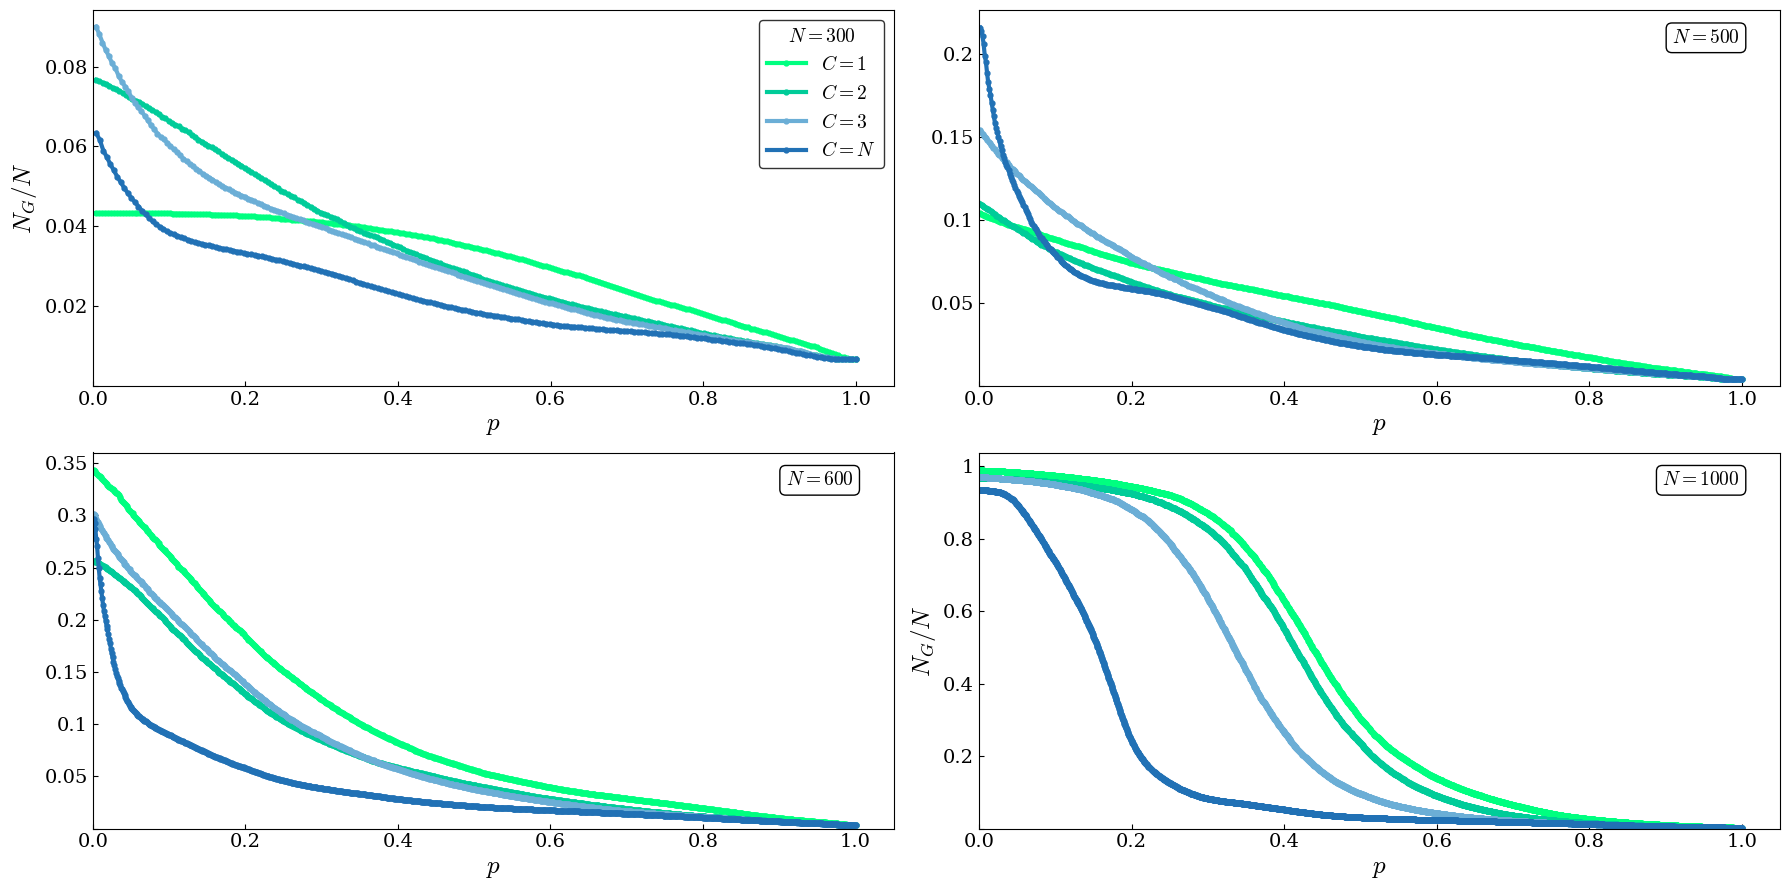

In [3]:
plot_m1_multi_layout("random", prefer_tex=False)
